In [1]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Definir la ruta de la base de datos
ruta_dataset = '/content/drive/MyDrive/Proyecto PALTA/Imagenes'

Mounted at /content/drive


In [2]:
# =========================
# 1. Importar librerías
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


# =========================
# 2. Parámetros
# =========================
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50


In [4]:
# =========================
# 3. Cargar dataset
# =========================
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    ruta_dataset,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
n_classes = len(class_names)
print("Clases:", class_names)

# =========================
# 4. Función para dividir dataset
# =========================
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

# Optimización de carga
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 450 files belonging to 3 classes.
Clases: ['PaltaArañitaRoja', 'PaltaManchadoSolar', 'PaltaSana']


In [5]:
# =========================
# Capa personalizada HSV
# =========================
class HSVHighlightLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(HSVHighlightLayer, self).__init__(**kwargs)

    def call(self, inputs):
        # Normalizar a [0,1]
        x = inputs / 255.0
        hsv = tf.image.rgb_to_hsv(x)

        # Rangos de rojo/marrón
        lower_red1 = tf.constant([0.0, 0.2, 0.2])
        upper_red1 = tf.constant([0.05, 1.0, 1.0])
        lower_red2 = tf.constant([0.95, 0.2, 0.2])
        upper_red2 = tf.constant([1.0, 1.0, 1.0])

        # Máscaras
        mask1 = tf.reduce_all(hsv >= lower_red1, axis=-1) & tf.reduce_all(hsv <= upper_red1, axis=-1)
        mask2 = tf.reduce_all(hsv >= lower_red2, axis=-1) & tf.reduce_all(hsv <= upper_red2, axis=-1)
        mask = tf.cast(mask1 | mask2, tf.float32)

        # Expandir canal y concatenar
        mask = tf.expand_dims(mask, axis=-1)
        out = tf.concat([x, mask], axis=-1)  # -> 4 canales
        return out

# =========================
# 5. Preprocesamiento y Aumento
# =========================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# =========================
# 6. Definir modelo
# =========================
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    layers.Input(shape=input_shape),
    HSVHighlightLayer(),
    data_augmentation,
    layers.Conv2D(32, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hsv_highlight_layer             │ (None, 256, 256, 4)    │             0 │
│ (HSVHighlightLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 252, 252, 32)   │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,797,987 (22.12 MB)

 Trainable params: 5,797,987 (22.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# 7. Callbacks (solo ReduceLROnPlateau)
# =========================
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Define la ruta donde quieres guardar tu modelo en Drive
ruta_guardado_modelo = "/content/drive/MyDrive/Modelos_CNN/Mejor_Modelo.keras"

# Asegúrate de que el directorio exista (opcional pero recomendado)
os.makedirs(os.path.dirname(ruta_guardado_modelo), exist_ok=True)

checkpoint = ModelCheckpoint(
    ruta_guardado_modelo,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# =========================
# 8. Entrenar
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[reduce_lr, checkpoint]
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3303 - loss: 1.2160
Epoch 1: val_loss improved from inf to 1.08280, saving model to /content/drive/MyDrive/Modelos_CNN/Mejor_Modelo.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 182s 9s/step - accuracy: 0.3314 - loss: 1.2116 - val_accuracy: 0.4688 - val_loss: 1.0828 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4094 - loss: 1.0489
Epoch 2: val_loss improved from 1.08280 to 0.97590, saving model to /content/drive/MyDrive/Modelos_CNN/Mejor_Modelo.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 85s 7s/step - accuracy: 0.4146 - loss: 1.0447 - val_accuracy: 0.5312 - val_loss: 0.9759 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5645 - loss: 0.8357
Epoch 3: val_loss improved from 0.97590 to 0.61135, saving model to /content/drive/MyDrive/Modelos_CNN/Mejor_Modelo.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 88s 7s/step - accuracy: 0.5663 - loss: 0.8320 - val_accuracy: 0.6875 - val_loss: 0.

2/2 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.8438 - loss: 0.4473

Precisión Global del Modelo (Accuracy): 0.8594
Test Loss Global: 0.4120


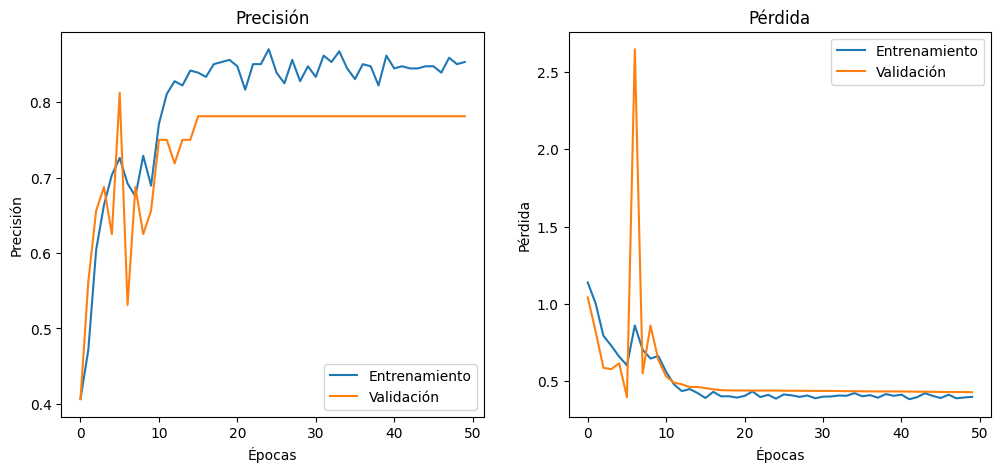


Generando reporte de clasificación y matriz de confusión...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


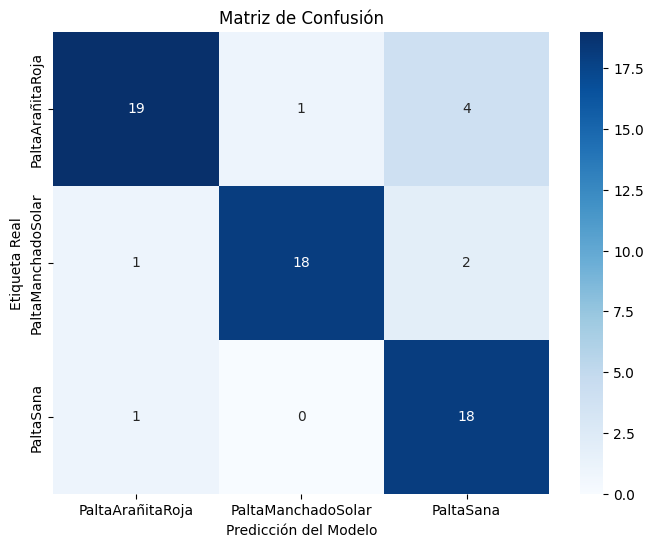


Reporte de Clasificación por Clase:
                    precision    recall  f1-score   support

 PaltaArañitaRoja       0.90      0.79      0.84        24
PaltaManchadoSolar       0.95      0.86      0.90        21
         PaltaSana       0.75      0.95      0.84        19

          accuracy                           0.86        64
         macro avg       0.87      0.87      0.86        64
      weighted avg       0.87      0.86      0.86        64


Métricas Globales (Promedio Ponderado):
Precisión Ponderada: 0.8728
Recall Ponderado: 0.8594
F1-Score Ponderado: 0.8605
Soporte Total: 64.0
---


In [ ]:
# =========================
# 9. Evaluar en test
# =========================
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nPrecisión Global del Modelo (Accuracy): {test_acc:.4f}")
print(f"Test Loss Global: {test_loss:.4f}")

# =========================
# 10. Graficar entrenamiento
# =========================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida')
plt.show()

# =========================
# 11. Matriz de confusión y Reporte de Clasificación
# =========================
print("\nGenerando reporte de clasificación y matriz de confusión...")
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción del Modelo")
plt.ylabel("Etiqueta Real")
plt.title("Matriz de Confusión")
plt.show()

# Reporte de Clasificación por clase
print("\nReporte de Clasificación por Clase:")
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=class_names))

# Extraer y mostrar métricas globales

print("\nMétricas Globales (Promedio Ponderado):")
print(f"Precisión Ponderada: {report['weighted avg']['precision']:.4f}")
print(f"Recall Ponderado: {report['weighted avg']['recall']:.4f}")
print(f"F1-Score Ponderado: {report['weighted avg']['f1-score']:.4f}")
print(f"Soporte Total: {report['weighted avg']['support']}")
print("---")


In [6]:
# =========================
# 12. Funcion para predecir una imagen individual
# =========================

def predict_single_image(model_to_use, image_path, class_names_list):
    """
    Carga, preprocesa y predice la clase de una sola imagen.
    """
    print(f"Cargando imagen: {image_path}")

    # 1. Cargar la imagen desde la ruta
    img = tf.keras.preprocessing.image.load_img(
        image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)
    )

    # 2. Convertir la imagen a un array de numpy
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # 3. Expandir las dimensiones para que coincida con la entrada del modelo
    img_batch = tf.expand_dims(img_array, axis=0)

    # 4. Realizar la predicción

    predictions = model_to_use.predict(img_batch, verbose=0)

    # 5. Interpretar los resultados

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names_list[predicted_index]
    confidence = 100 * np.max(predictions[0])

    # 6. Mostrar la imagen y el resultado
    plt.figure(figsize=(6, 4))
    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Predicción: {predicted_class}\nConfianza: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print(f"Clase Predicha: {predicted_class}")
    print(f"Confianza: {confidence:.2f}%")

# =========================
# 13. ¡Llamada a la función!
# =========================

# NOTA: 'ruta_guardado_modelo' se definió en la Sección 7
print(f"\nCargando el mejor modelo guardado desde: {ruta_guardado_modelo}")

best_model = tf.keras.models.load_model(
    ruta_guardado_modelo,  # <--- ¡CORRECCIÓN! Usa la misma variable
    custom_objects={'HSVHighlightLayer': HSVHighlightLayer}
)
print("¡Modelo cargado!")


# --- Tu ruta de imagen de prueba (esto está perfecto) ---
ruta_a_tu_imagen = '/content/drive/MyDrive/Proyecto PALTA/Testeo/IMG_20251120_161438.jpg'

try:
    # 5. Aquí es donde se "llama" a la función con tu ruta
    predict_single_image(best_model, ruta_a_tu_imagen, class_names)

except FileNotFoundError:
    print(f"\nERROR: No se encontró el archivo en '{ruta_a_tu_imagen}'.")
    print("Asegúrate de que la ruta sea correcta y el archivo esté subido.")
except Exception as e:
    print(f"\nERROR: {e}")
    print("Asegúrate de que 'class_names' y 'HSVHighlightLayer' estén definidos.")


NameError: name 'ruta_guardado_modelo' is not defined

Found 450 files belonging to 3 classes.
Clases: ['PaltaArañitaRoja', 'PaltaManchadoSolar', 'PaltaSana']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hsv_highlight_layer             │ (None, 256, 256, 4)    │             0 │
│ (HSVHighlightLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 252, 252, 32)   │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,797,987 (22.12 MB)

 Trainable params: 5,797,987 (22.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 287s 14s/step - accuracy: 0.3170 - loss: 1.8597 - val_accuracy: 0.4688 - val_loss: 1.0644 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 135s 11s/step - accuracy: 0.3566 - loss: 1.1057 - val_accuracy: 0.4688 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 131s 11s/step - accuracy: 0.4253 - loss: 1.0410 - val_accuracy: 0.3750 - val_loss: 1.5314 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 145s 11s/step - accuracy: 0.4437 - loss: 1.2184 - val_accuracy: 0.4688 - val_loss: 0.7298 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 145s 12s/step - accuracy: 0.4784 - loss: 0.9056 - val_accuracy: 0.7188 - val_loss: 0.6744 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 134s 11s/step - accuracy: 0.5971 - loss: 0.8796 - val_accuracy: 0.7188 - val_loss: 0.5340 - learning_rate: 0.0010
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 133s 11s/step - accuracy: 0.5867 - loss: 0.8672 - 

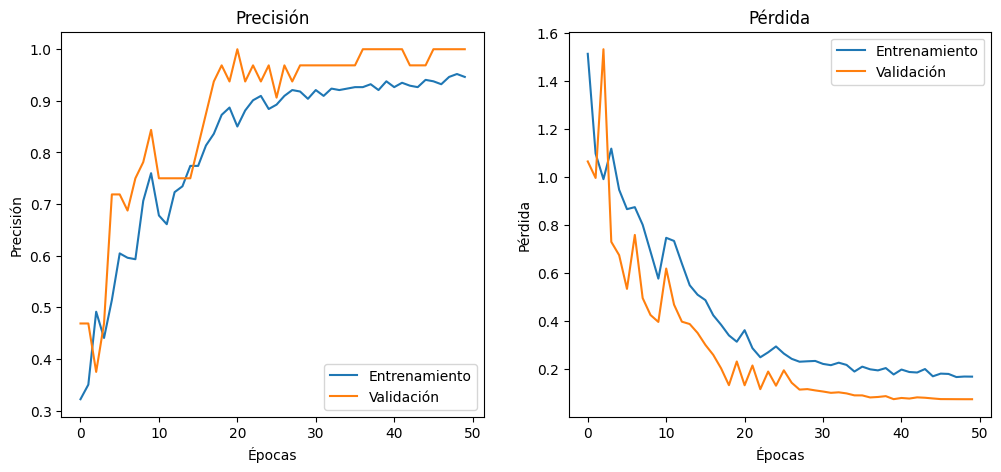


Generando reporte de clasificación y matriz de confusión...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


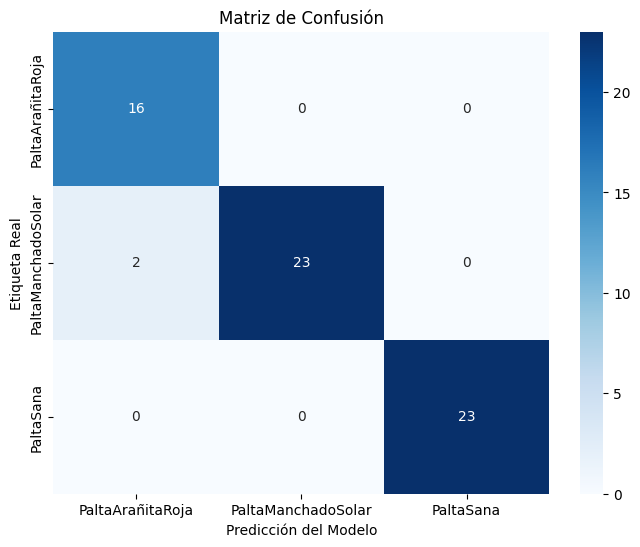


Reporte de Clasificación por Clase:
                    precision    recall  f1-score   support

 PaltaArañitaRoja       0.89      1.00      0.94        16
PaltaManchadoSolar       1.00      0.92      0.96        25
         PaltaSana       1.00      1.00      1.00        23

          accuracy                           0.97        64
         macro avg       0.96      0.97      0.97        64
      weighted avg       0.97      0.97      0.97        64


Métricas Globales (Promedio Ponderado):
Precisión Ponderada: 0.9722
Recall Ponderado: 0.9688
F1-Score Ponderado: 0.9690
Soporte Total: 64.0
---


In [ ]:
# =========================
# Medir FLOPs
# =========================
print("\nMidiendo FLOPs del modelo (Método TF 2.x)...")

# 1. Obtener la "Función Concreta" del modelo
# Esto traza el modelo con una entrada de muestra y genera un grafo
full_model = tf.function(model)
concrete_func = full_model.get_concrete_function(
    tf.TensorSpec(shape=[1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS], dtype=tf.float32)
)

# 2. Importar el profiler (pueden ser internos, por eso el .python)
try:
    from tensorflow.python.profiler.model_analyzer import profile
    from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

    # 3. Definir las opciones para contar operaciones de punto flotante
    profile_options = ProfileOptionBuilder(ProfileOptionBuilder.float_operation()).build()

    # 4. Perfilar el grafo de la función concreta
    flops_profile = profile(concrete_func.graph, options=profile_options)

    # 5. Obtener el total de FLOPs
    total_flops = flops_profile.total_float_ops

    if total_flops == 0:
        print("ADVERTENCIA: FLOPs reportados son 0. Esto puede ser un error del profiler.")
    else:
        # Imprimir en GFLOPs (Giga-FLOPs), que es más estándar
        print(f"\nFLOPs totales del modelo: {total_flops}")
        print(f"GFLOPs (Giga-FLOPs): {total_flops / 1e9:.4f}")

except ImportError as e:
    print(f"No se pudo importar el profiler: {e}")
    print("La medición de FLOPs no está disponible. Omitiendo.")

print("\n--- Fin del script ---")